# Measles Multistrade Project


## Neccesay Pythomn & EpiMoRPH Packages


In [1]:
from sympy import symbols, Matrix

from sympy import Max,  parse_expr
from sympy import symbols, Matrix

from epymorph import *
from epymorph.compartment_model import *
from epymorph.data_shape import Shapes
from epymorph.geo.adrio import adrio_maker_library
from epymorph.geo.dynamic import DynamicGeo
from epymorph.geo.spec import DynamicGeoSpec, Year
from epymorph.geography.us_census import CountyScope
from epymorph.simulation import AttributeDef

## Constructing IPM


In [2]:
def construct_ipm():
    symbols = create_symbols(
        compartments=[
            compartment('S'),
            compartment('E'),
            compartment('I'),
            compartment('R'),
            compartment('VS_1'),
            compartment('VR_1'),
            compartment('V_2'),
        ],
        attributes=[
            AttributeDef('beta_s', float, shape=Shapes.TxN),
            AttributeDef('beta_v', float, shape=Shapes.TxN),
            AttributeDef('alpha', float, shape=Shapes.TxN),
            AttributeDef('gamma', float, shape=Shapes.TxN),
            AttributeDef('omega', float, shape=Shapes.TxN),
        ])

    [S, E, I, R, VS_1, VR_1, V_2] = symbols.compartment_symbols
    [β_s, β_v, α, γ, ω] = symbols.attribute_symbols

    N = Max(1, S, E, I, R, VS_1, VR_1, V_2)

    return create_model(
        symbols=symbols,
        transitions=[
            edge(S, E, rate = β_s * S * I / N),
            edge(E, I, rate = (1/α) * E),
            edge(I, R, rate = (1/γ) * I),
            
            edge(VS_1, E, rate = β_v * VS_1 * I / N),
            edge(VS_1, V_2, rate = ω * VS_1),
            
            edge(VR_1, V_2, rate = ω * V_2),
        ]
    )

School_ipm = construct_ipm()

## Constructing Geo


In [16]:
# (cheater cell) load/create multistrata GEO
import os
from functools import partial

import numpy as np
import pandas as pd
from census import Census

from epymorph.data_type import CentroidDType
from epymorph.geo.spec import NO_DURATION, StaticGeoSpec
from epymorph.geo.static import StaticGeo
from epymorph.geography.us_census import BLOCK_GROUP, BlockGroupScope
from epymorph.geography.us_census import TRACT, TractScope
from epymorph.geography.us_tiger import get_tracts_geo


def fetch_geo(scope: BlockGroupScope):
    census = Census(os.environ.get('CENSUS_API_KEY'))

    def query_pop_by_age(state_fips: str, county_fips: str, tract_ids: list[str]):
        query_result = census.acs5.get(
            'group(B01001)',
            geo={'for': f'tract:{",".join(tract_ids)}',
                 'in': f'state:{state_fips} county:{county_fips}'},
            year=2021,
        )

        raw_df = pd.DataFrame.from_records(query_result).astype({
            'state': np.str_,
            'county': np.str_,
            'tract': np.str_,
        })

        def group_cols(first: int, last: int, *, source: pd.DataFrame, table: str, dtype) -> pd.Series:
            def est_name(line: int) -> str:
                return f"{table}_{line:03d}E"
            result = source[est_name(first)]
            for i in range(first + 1, last + 1):
                result = result + source[est_name(i)]
            return result.astype(dtype)

        group = partial(group_cols, source=raw_df, table='B01001', dtype=np.int64)

        tracts_gdf = get_block_groups_geo(year=scope.year)  # type: ignore
        calc_centroid = lambda x: x.centroid.coords[0]
        centroid_df = pd.DataFrame({
            'geoid': tracts_gdf['GEOID'].astype(str),
            'centroid': tracts_gdf['geometry'].apply(calc_centroid),
        })

        return pd.DataFrame({
            'geoid': raw_df['state'] + raw_df['county'] + raw_df['tract'],
            'population_00-19': group(3, 8) + group(27, 32),
            'population_20-59': group(9, 17) + group(33, 41),
            'population_60-79': group(18, 24) + group(42, 48),
        }).merge(centroid_df, on='geoid', how='left')

    geoid_parts = list(map(BLOCK_GROUP.decompose, scope.get_node_ids()))

    # Assumes our scope only contains one state and one county (which it should)
    age_df = query_pop_by_age(
        state_fips=geoid_parts[0][0],
        county_fips=geoid_parts[0][1],
        tract_ids=[t for _, _, t in geoid_parts],
    )

    age_df['population'] = age_df['population_00-19'] + \
        age_df['population_20-59'] + age_df['population_60-79']

    return StaticGeo(
        spec=StaticGeoSpec(
            scope=scope,
            attributes=[
                AttributeDef('label', str, Shapes.N),
                AttributeDef('geoid', str, Shapes.N),
                AttributeDef('centroid', CentroidType, Shapes.N),
                AttributeDef('population', int, Shapes.N),
                AttributeDef('population_00-19', int, Shapes.N),
                AttributeDef('population_20-59', int, Shapes.N),
                AttributeDef('population_60-79', int, Shapes.N),
            ],
            time_period=NO_DURATION,
        ),
        values={
            'label': age_df['geoid'].to_numpy(dtype=np.str_),
            'geoid': age_df['geoid'].to_numpy(dtype=np.str_),
            'centroid': age_df['centroid'].to_numpy(dtype=CentroidDType),
            'population': age_df['population'].to_numpy(dtype=SimDType),
            'population_00-19': age_df['population_00-19'].to_numpy(dtype=SimDType),
            'population_20-59': age_df['population_20-59'].to_numpy(dtype=SimDType),
            'population_60-79': age_df['population_60-79'].to_numpy(dtype=SimDType),
        },
    )

In [17]:
# Example 4: multistrata simulations

from epymorph.geography.us_census import BlockGroupScope

# Select 21 census tracts out of Maricopa County, AZ
scope = BlockGroupScope.in_counties(['04013'], year=2020)

#subset_tracts = maricopa_tracts.get_node_ids()

#scope = BlockGroupScope.in_tracts(subset_tracts.tolist())

print(f"The census tracts we'll model:\n{scope.get_node_ids()}")

The census tracts we'll model:
['040130101021' '040130101022' '040130101023' ... '040139807001'
 '040139809001' '040139810001']


In [19]:
geo_df = geo.values
geo_df = pd.DataFrame({k: list(v) for k, v in geo_df.items()})
geo_df.head()


,centroid,geoid,label,population,population_00-19,population_20-59,population_60-79
0,"[-111.54700278181355, 33.74364068652288]",04013010102,04013010102,5283,517,1686,3080
1,"[-113.06194383820676, 33.316494986127395]",04013050603,04013050603,5708,1336,3033,1339
2,"[-112.401743531251, 33.63148322770842]",04013061027,04013061027,6378,1911,3551,916
3,"[-112.43090352148347, 33.63157295278307]",04013061061,04013061061,4908,1941,2327,640
4,"[-112.24568889975045, 33.589219977060395]",04013071913,04013071913,6128,1995,3091,1042


## LEHD Origin-Destination Employment Statistics (LODES) Adrio


In [45]:
spec = DynamicGeoSpec(
    attributes=[
        AttributeDef('label', str, Shapes.N),
        AttributeDef('commuters_29_under', int, Shapes.NxN),
        AttributeDef('commuters_30_to_54', int, Shapes.NxN),
        AttributeDef('commuters_55_over', int, Shapes.NxN),
    ],
    time_period=Year(2019),
    scope=CountyScope.in_counties(["04013", "08041", "32003", "35001"]),
    source={
        'label': 'LODES:geoid',
        'commuters_29_under': 'LODES',
        'commuters_30_to_54': 'LODES',
        'commuters_55_over': 'LODES',
    }
)

geo = DynamicGeo.from_library(spec, adrio_maker_library)

print(f"Commuters ages 29 and under:\n {geo['commuters_29_under']}\n")

print(f"Commuters between ages 30 and 54:\n {geo['commuters_30_to_54']}\n")

print(f"Commuters ages 55 and over:\n {geo['commuters_55_over']}\n")

Commuters ages 29 and under:
 [[427679      7    394    216]
 [    19  48960     12     17]
 [   368      4 217938     46]
 [   162     29     55  58239]]

Commuters between ages 30 and 54:
 [[993087     32   1135    440]
 [    53 110413     32     37]
 [   734     23 536234    101]
 [   226     30    123 134122]]

Commuters ages 55 and over:
 [[401873     10    384    189]
 [    30  49007     13     15]
 [   342      3 213243     50]
 [   109     21     57  60599]]



## Constucting Multistrade


In [8]:
from functools import partial, reduce

import matplotlib.pyplot as plt

from epymorph import *
from epymorph.compartment_model import TransitionDef, edge
from epymorph.geo.cache import load_from_cache

geo = load_from_cache(
    'Maricopa_CBG',
    or_else=partial(fetch_geo, scope)
)

# age_00-19
gpm1 = Gpm(
    ipm=ipm_library['sirs'](),
    mm=mm_library['centroids'](),
    init=init.NoInfection(),
)

# age_20-59
gpm2 = Gpm(
    ipm=ipm_library['sirs'](),
    mm=mm_library['centroids'](),
    init=init.SingleLocation(location=0, seed_size=100),
)

# age_60-79
gpm3 = Gpm(
    ipm=ipm_library['sirs'](),
    mm=mm_library['no'](),
    init=init.NoInfection(),
)


meta_attributes = [
    AttributeDef("beta_12", float, Shapes.TxN),
    AttributeDef("beta_13", float, Shapes.TxN),
    AttributeDef("beta_21", float, Shapes.TxN),
    AttributeDef("beta_23", float, Shapes.TxN),
    AttributeDef("beta_31", float, Shapes.TxN),
    AttributeDef("beta_32", float, Shapes.TxN),
]


def build_meta_edges(rs: RumeSymbols) -> list[TransitionDef]:
    # extract compartment symbols by strata
    S_1, I_1, R_1 = rs.compartments("age_00-19")
    S_2, I_2, R_2 = rs.compartments("age_20-59")
    S_3, I_3, R_3 = rs.compartments("age_60-79")

    # extract compartment totals by strata
    N_1 = rs.total_nonzero("age_00-19")
    N_2 = rs.total_nonzero("age_20-59")
    N_3 = rs.total_nonzero("age_60-79")

    # extract meta attributes
    beta_12, beta_13, beta_21, beta_23, beta_31, beta_32 = rs.meta_attributes()

    return [
        edge(S_1, I_1, rate=S_1 * beta_12 * I_2 / N_2),  # 2 infects 1
        edge(S_1, I_1, rate=S_1 * beta_13 * I_3 / N_3),  # 3 infects 1
        edge(S_2, I_2, rate=S_2 * beta_21 * I_1 / N_1),  # 1 infects 2
        edge(S_2, I_2, rate=S_2 * beta_23 * I_3 / N_3),  # 3 infects 2
        edge(S_3, I_3, rate=S_3 * beta_31 * I_1 / N_1),  # 1 infects 3
        edge(S_3, I_3, rate=S_3 * beta_32 * I_2 / N_2),  # 2 infects 3
    ]

## Simulation


In [9]:
rume = Rume.multistrata(
    strata=[
        ("age_00-19", gpm1),
        ("age_20-59", gpm2),
        ("age_60-79", gpm3),
    ],
    meta_attributes=meta_attributes,
    meta_edges=build_meta_edges,
    scope=scope,
    time_frame=TimeFrame.of("2020-01-01", 180),
    params={
        # IPM params
        "gpm:age_00-19::ipm::beta": 0.05,
        "gpm:age_20-59::ipm::beta": 0.20,
        "gpm:age_60-79::ipm::beta": 0.35,
        "*::ipm::gamma": 1 / 10,
        "*::ipm::xi": 1 / 90,
        "meta::ipm::beta_12": 0.05,
        "meta::ipm::beta_13": 0.05,
        "meta::ipm::beta_21": 0.20,
        "meta::ipm::beta_23": 0.20,
        "meta::ipm::beta_31": 0.35,
        "meta::ipm::beta_32": 0.35,

        # MM params
        "gpm:age_00-19::mm::phi": 20.0,
        "gpm:age_20-59::mm::phi": 40.0,
        "gpm:age_60-79::mm::phi": 30.0,

        # Things provided by geo
        "*::*::centroid": geo['centroid'],
        "gpm:age_00-19::*::population": geo['population_00-19'],
        "gpm:age_20-59::*::population": geo['population_20-59'],
        "gpm:age_60-79::*::population": geo['population_60-79'],
    },
)

sim = BasicSimulator(rume)
with sim_messaging(sim):
    out = sim.run()


Traceback (most recent call last):
  File "/Users/alexandernez/Desktop/Github/Epymorph_vignettes/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/_v/4q2_l88n1vndy51_ksbfylnc0000gn/T/ipykernel_16286/534222045.py", line 40, in <module>
    out = sim.run()
          ^^^^^^^^^
  File "/Users/alexandernez/Desktop/Github/Epymorph_vignettes/epymorph/simulator/basic/basic_simulator.py", line 72, in run
    raise SimValidationException(msg) from None
epymorph.error.SimValidationException: RUME attribute requirements were not met. See errors:
- Attribute 'gpm:age_00-19::mm::population' is not properly specified. Not a numpy shape match: got (21,), expected N
- Attribute 'gpm:age_00-19::mm::centroid' is not properly specified. Not a numpy shape match: got (21,), expected N
- Attribute 'gpm:age_00-19::init::population' is not properly specified. Not a numpy shape match: got (21,),

In [42]:
import numpy as np

def job(dummy_arg):
    sim = BasicSimulator(rume)

    out = sim.run()
    prevalence_array = [np.sum(out.prevalence[i, :, 1], axis=0) for i in range(150*2)]
    return prevalence_array


Running simulation (BasicSimulator):Running simulation (BasicSimulator):

• 2020-01-01 to 2020-06-29 (180 days)• 2020-01-01 to 2020-06-29 (180 days)

• 21 geo nodes• 21 geo nodes

|################### | 99%                     | 0% |                    | 0% |                    | 0% |                    | 1% |                    | 1% |                    | 1% |                    | 1% |                    | 1% |                    | 1% |                    | 1% |                    | 1% |                    | 2% |                    | 3% |                    | 3% |                    | 3% |                    | 4% |#                   | 7% |#                   | 7% |#                   | 7% |#                   | 7% |#                   | 7% |#                   | 8% |#                   | 8% |#                   | 8% |#                   | 8% |#                   | 8% |#                   | 9% |#                   | 9% |#                   | 9% |#                   | 9% |#            

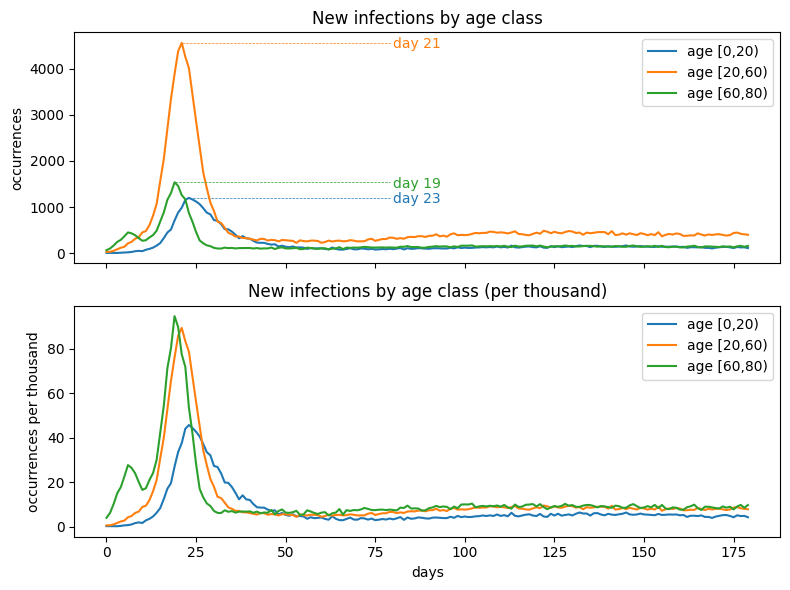

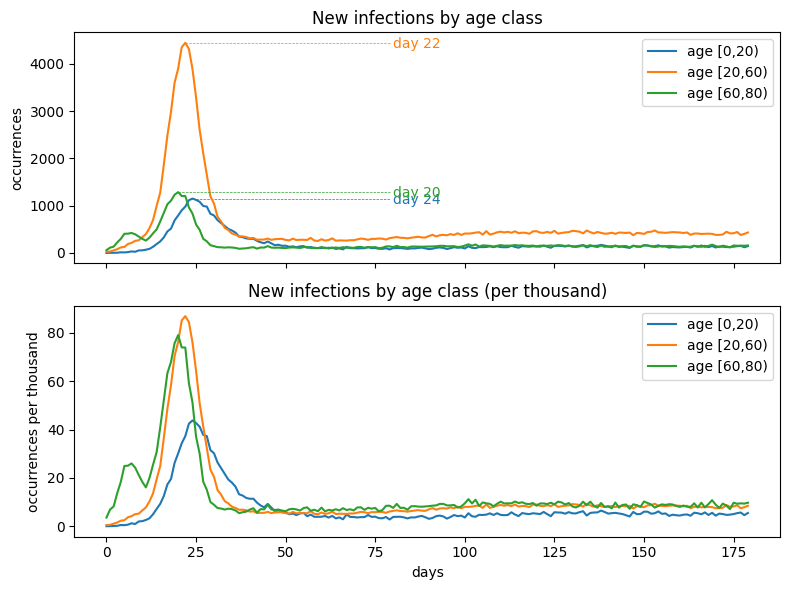

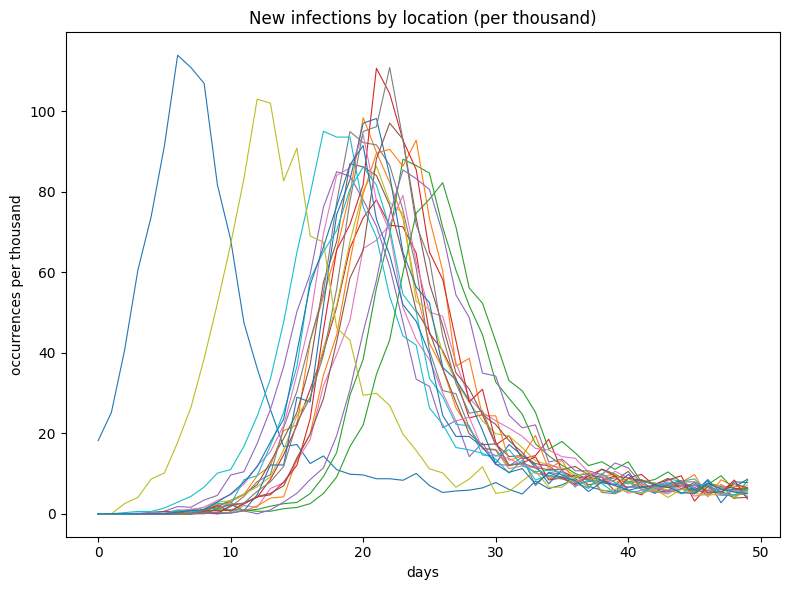

got here


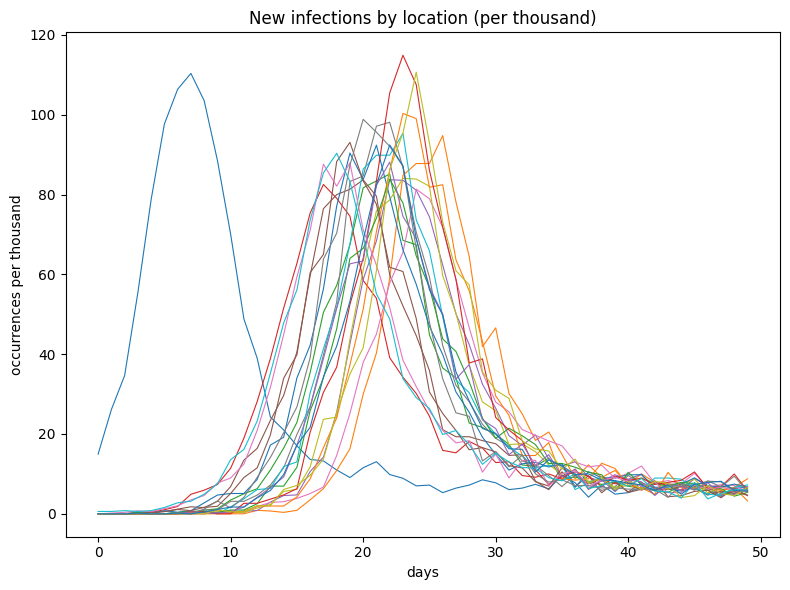

got here


In [38]:
import multiprocessing
from multiprocessing import get_context
from functools import partial

from epymorph import *

cpu_25 = int(multiprocessing.cpu_count() * 0.25) # Using 2 CPU cores
cpu_50 = int(multiprocessing.cpu_count() * 0.50) # Using 4 CPU cores
cpu_75 = int(multiprocessing.cpu_count() * 0.75) # Using 6 CPU cores
cpu_100 = multiprocessing.cpu_count() # Using all CPU cores

def job(weekday_phis: int, weekend_phis: int, output_name: str) -> None:
    sim = BasicSimulator(rume)
    
    with sim_messaging(sim):
        out = sim.run()
    # calc total new infections (depending on the IPM this may represent this as separate events)
    infection_events = [
        rume.ipm.events_by_dst("I_age_00-19"),
        rume.ipm.events_by_dst("I_age_20-59"),
        rume.ipm.events_by_dst("I_age_60-79"),
    ]   

    infections = np.array([
        reduce(lambda a, b: a + b,
            (out.incidence_per_day[:, :, j].sum(axis=1) for j in infection_events[i]))
        for i in [0, 1, 2]
    ])

    ### GRAPHS ###


    # Plot infections by age class
    age_label = ['age [0,20)', 'age [20,60)', 'age [60,80)']
    age_total_thousands = np.column_stack(
        [geo['population_00-19'], geo['population_20-59'], geo['population_60-79']]).sum(axis=0) / 1000
    t_window = slice(0, None)

    # Day of Peak Infection by age class
    dpi = [
        int(np.argmax(infections[i]))
        for i in [0, 1, 2]
    ]
    max_y_value = infections.max()
    dpi_x_pos = 80  # an absolute x offset (to keep them horizontally aligned)
    dpi_y_pos = -0.025 * max_y_value  # an offset from the peak's y position

    fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
    x_axis = np.arange(out.dim.days)[t_window]

    ax1.set_title('New infections by age class')
    ax1.set_ylabel('occurrences')
    for i in [0, 1, 2]:
        color = ax1._get_lines.get_next_color()
        y_axis = infections[i][t_window]
        ax1.plot(x_axis, y_axis, color=color, label=age_label[i])
        # Mark day of peak infection
        d = dpi[i]
        ax1.text(dpi_x_pos, y_axis[d] + dpi_y_pos, f"day {d}", color=color)
        ax1.hlines(y=y_axis[d], xmin=d, xmax=dpi_x_pos - 1,
                color=color, linewidth=0.5, linestyle='dashed')
    ax1.legend()

    ax2.set_title('New infections by age class (per thousand)')
    ax2.set_xlabel('days')
    ax2.set_ylabel('occurrences per thousand')
    for i in [0, 1, 2]:
        y_axis = infections[i][t_window] / age_total_thousands[i]
        ax2.plot(x_axis, y_axis, label=age_label[i])
    ax2.legend()

    fig.tight_layout()
    plt.show()


    # Plot infections by location
    pop_label = geo['label']
    pop_total_thousands = geo['population'] / 1000

    t_window = slice(0, 50)

    infections_by_loc = out.incidence_per_day[:, :, rume.ipm.events_by_dst("I_age_*")]\
        .sum(axis=2, dtype=np.int64)

    fig, ax = plt.subplots(figsize=(8, 6))
    x_axis = np.arange(out.dim.days)[t_window]
    ax.set_title('New infections by location (per thousand)')
    ax.set_xlabel('days')
    ax.set_ylabel('occurrences per thousand')
    for n in range(geo.nodes):
        y_axis = infections_by_loc[t_window, n] / pop_total_thousands[n]
        ax.plot(x_axis, y_axis, linewidth=0.8)

    fig.tight_layout()
    plt.show()
    print("got here")

args = []
weekday_phis = [10]
weekend_phis = [10]
for wday_phi in weekday_phis:
    for wend_phi in weekend_phis:
        args.extend([(wday_phi, wend_phi, f'scratch/Multiprocessing/sim-run-wday-{wday_phi}-wend-{wend_phi}-{i}.csv') for i in range(2)])

p = get_context("fork").Pool(cpu_75)
results = p.starmap(job, args)
p.close()
p.join()

# Plots


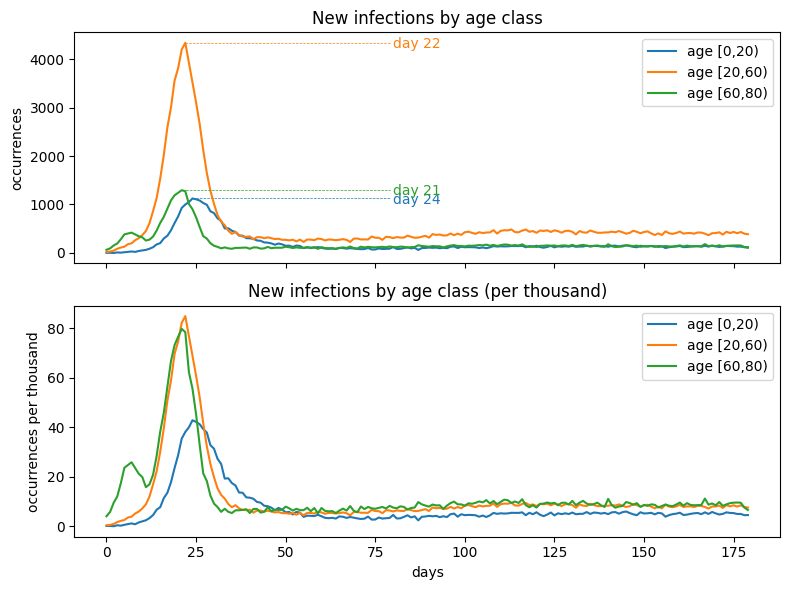

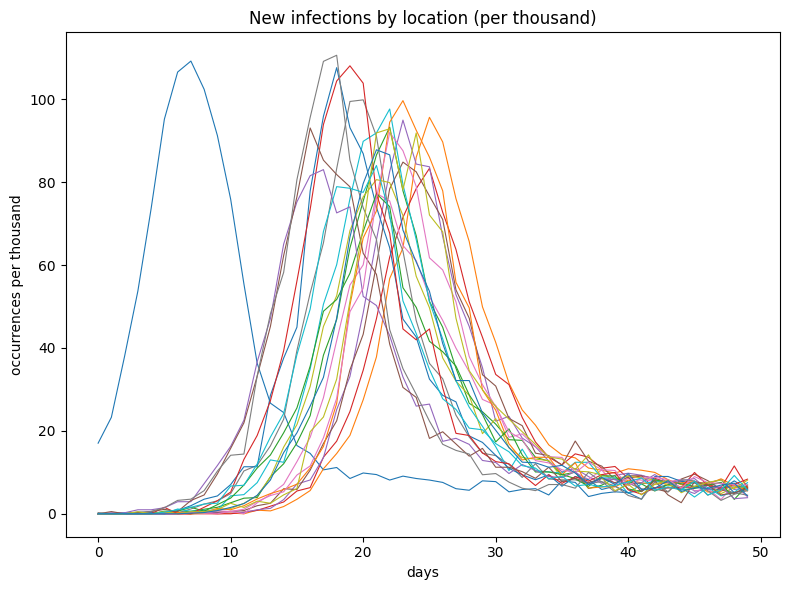

In [21]:
# calc total new infections (depending on the IPM this may represent this as separate events)
infection_events = [
    rume.ipm.events_by_dst("I_age_00-19"),
    rume.ipm.events_by_dst("I_age_20-59"),
    rume.ipm.events_by_dst("I_age_60-79"),
]

infections = np.array([
    reduce(lambda a, b: a + b,
           (out.incidence_per_day[:, :, j].sum(axis=1) for j in infection_events[i]))
    for i in [0, 1, 2]
])

### GRAPHS ###


# Plot infections by age class
age_label = ['age [0,20)', 'age [20,60)', 'age [60,80)']
age_total_thousands = np.column_stack(
    [geo['population_00-19'], geo['population_20-59'], geo['population_60-79']]).sum(axis=0) / 1000
t_window = slice(0, None)

# Day of Peak Infection by age class
dpi = [
    int(np.argmax(infections[i]))
    for i in [0, 1, 2]
]
max_y_value = infections.max()
dpi_x_pos = 80  # an absolute x offset (to keep them horizontally aligned)
dpi_y_pos = -0.025 * max_y_value  # an offset from the peak's y position

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
x_axis = np.arange(out.dim.days)[t_window]

ax1.set_title('New infections by age class')
ax1.set_ylabel('occurrences')
for i in [0, 1, 2]:
    color = ax1._get_lines.get_next_color()
    y_axis = infections[i][t_window]
    ax1.plot(x_axis, y_axis, color=color, label=age_label[i])
    # Mark day of peak infection
    d = dpi[i]
    ax1.text(dpi_x_pos, y_axis[d] + dpi_y_pos, f"day {d}", color=color)
    ax1.hlines(y=y_axis[d], xmin=d, xmax=dpi_x_pos - 1,
               color=color, linewidth=0.5, linestyle='dashed')
ax1.legend()

ax2.set_title('New infections by age class (per thousand)')
ax2.set_xlabel('days')
ax2.set_ylabel('occurrences per thousand')
for i in [0, 1, 2]:
    y_axis = infections[i][t_window] / age_total_thousands[i]
    ax2.plot(x_axis, y_axis, label=age_label[i])
ax2.legend()

fig.tight_layout()
plt.show()


# Plot infections by location
pop_label = geo['label']
pop_total_thousands = geo['population'] / 1000

t_window = slice(0, 50)

infections_by_loc = out.incidence_per_day[:, :, rume.ipm.events_by_dst("I_age_*")]\
    .sum(axis=2, dtype=np.int64)

fig, ax = plt.subplots(figsize=(8, 6))
x_axis = np.arange(out.dim.days)[t_window]
ax.set_title('New infections by location (per thousand)')
ax.set_xlabel('days')
ax.set_ylabel('occurrences per thousand')
for n in range(geo.nodes):
    y_axis = infections_by_loc[t_window, n] / pop_total_thousands[n]
    ax.plot(x_axis, y_axis, linewidth=0.8)

fig.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from geopy.distance import great_circle

# Sample DataFrames for demonstration
WVN_data = {
    'INTPTLAT20': [33.3178283, 34.052235, 40.712776],
    'INTPTLON20': [-111.8305406, -118.243683, -74.005974],
    'WVN_Extra1': [1, 2, 3],  # Example additional columns
    'WVN_Extra2': ['A', 'B', 'C']
}
alert_data = {
    'Latitude DD': [33.3178283, 37.774929, 42.360081],
    'Longitude DD': [-111.8305406, -122.419418, -71.058884],
    'Station Name': ['Station1', 'Station2', 'Station3'],
    'Device ID': ['101', '102', '103'],
    'Dev. Type': ['TypeA', 'TypeB', 'TypeC'],
    'Installed': ['2020-01-01', '2021-01-01', '2022-01-01'],
    'Elevation': [10, 20, 30],
    'Station Location': ['Location1', 'Location2', 'Location3']
}

WVN_df = pd.DataFrame(WVN_data)
alert_df = pd.DataFrame(alert_data)

# Convert coordinates to numeric types
WVN_df['INTPTLAT20'] = WVN_df['INTPTLAT20'].astype(float)
WVN_df['INTPTLON20'] = WVN_df['INTPTLON20'].astype(float)
alert_df['Latitude DD'] = alert_df['Latitude DD'].astype(float)
alert_df['Longitude DD'] = alert_df['Longitude DD'].astype(float)

# Define a function to calculate the distance between two points using the Haversine formula
def calculate_distance(lat1, lon1, lat2, lon2):
    point1 = (lat1, lon1)
    point2 = (lat2, lon2)
    return great_circle(point1, point2).kilometers

results = []

# Iterate through the rows of WVN_df
for wvn_idx, wvn_row in WVN_df.iterrows():
    wvn_point = (wvn_row['INTPTLAT20'], wvn_row['INTPTLON20'])
    found_stations = []
    
    buffer_distance = 0.1  # Starting buffer distance in kilometers
    buffer_step = 0.1  # Increment step for buffer distance
    max_distance = 5.0  # Maximum buffer distance in kilometers

    while buffer_distance <= max_distance:
        for alert_idx, alert_row in alert_df.iterrows():
            alert_point = (alert_row['Latitude DD'], alert_row['Longitude DD'])
            distance = calculate_distance(wvn_point[0], wvn_point[1], alert_point[0], alert_point[1])
            
            if distance <= buffer_distance and alert_row not in found_stations:
                found_stations.append(alert_row)
                result = wvn_row.to_dict()
                result.update({
                    'Alert Latitude': alert_row['Latitude DD'],
                    'Alert Longitude': alert_row['Longitude DD'],
                    'Distance (km)': distance,
                    'Station Name': alert_row['Station Name'],
                    'Device ID': alert_row['Device ID'],
                    'Dev. Type': alert_row['Dev. Type'],
                    'Installed': alert_row['Installed'],
                    'Elevation': alert_row['Elevation'],
                    'Station Location': alert_row['Station Location']
                })
                results.append(result)
        
        buffer_distance += buffer_step  # Increment buffer distance

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Create a numpy array from the collected data
dtype = [('Distance (km)', 'f4'), ('Station Name', 'U50'), ('Device ID', 'U50'), ('Dev. Type', 'U50'), ('Installed', 'U50'), ('Elevation', 'f4'), ('Station Location', 'U50')]
structured_array = np.array([tuple(data.values()) for data in results], dtype=dtype)

print("Collected Data in Numpy Array:")
print(structured_array)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().